<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/logistic_regression_hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression — Hands-On Notebook
### Course: U23ADT306 – Basic Machine Learning Techniques (B.Tech AI & DS, Semester 3)

**Learning Objectives**
- Understand WHY Linear Regression is unsuitable for classification, and how the sigmoid function fixes this
- Perform EDA on a real-world classification dataset
- Handle missing values and encode categorical features for classification
- Train a Logistic Regression model using scikit-learn
- Evaluate a classifier using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC
- Interpret model coefficients in terms of odds

**Dataset:** Titanic - Machine Learning from Disaster
**Source (mirror):** https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
(This is the exact dataset used in Kaggle's famous "Titanic - Machine Learning from Disaster"
competition: https://www.kaggle.com/competitions/titanic)

**Target:** `Survived` (1 = survived, 0 = did not survive) -- a binary classification problem

**Estimated time:** 60–75 minutes


## 1. Environment Setup

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We install every library this notebook needs, so it runs identically
# on any machine (VS Code, Colab, or a fresh laptop).
# ------------------------------------------------------------------
import sys                      # sys -> gives access to the current Python interpreter path
import subprocess                # subprocess -> lets us call pip install from inside Python

required_packages = [
    "pandas",        # tabular data handling
    "numpy",         # numerical arrays
    "scikit-learn",  # model, preprocessing, metrics
    "matplotlib",    # plotting
    "seaborn"        # statistical plots (heatmaps, count plots)
]

for package in required_packages:
    # --break-system-packages keeps this working even on locked-down system Python installs
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", package])

print("All required packages are installed.")


All required packages are installed.


## 2. Dataset Download + Loading
We download the Titanic dataset directly from a public GitHub CSV mirror.

If your machine has the Kaggle CLI configured, you could alternatively run:
```
# import kagglehub
# path = kagglehub.dataset_download("competitions/titanic")
```


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We need the raw passenger data in memory before we can explore or model
# it. We download a real-world CSV directly from a public URL so every
# student gets the exact same data with zero manual upload or login required.
# ------------------------------------------------------------------
import pandas as pd   # pandas -> library for reading CSV files into DataFrames

# Public raw-CSV mirror of the Titanic dataset (identical to the Kaggle competition data)
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic_df = pd.read_csv(DATA_URL)   # download and parse the CSV directly into a DataFrame

# Display first 5 rows to sanity-check column names and values
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We check dataset size and column data types before doing anything else.
# ------------------------------------------------------------------
print("Shape of dataset (rows, columns):", titanic_df.shape)   # (num_passengers, num_columns)
print()
print("Data types of each column:")
print(titanic_df.dtypes)   # 'Sex', 'Embarked', 'Name', 'Ticket', 'Cabin' are text (object) columns


Shape of dataset (rows, columns): (891, 12)

Data types of each column:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Missing values must be found and quantified before we decide how to
# handle each one -- Titanic is a classic example with real missing data
# in 'Age', 'Cabin', and 'Embarked'.
# ------------------------------------------------------------------
missing_per_column = titanic_df.isnull().sum()   # count NaNs per column
print("Missing values per column:")
print(missing_per_column[missing_per_column > 0])   # show only columns that actually have missing values


Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Summary statistics give a quick feel for the numeric columns (e.g. Age
# range, Fare range) and help spot outliers (e.g. very high ticket fares).
# ------------------------------------------------------------------
titanic_df.describe()   # count, mean, std, min, quartiles, max per numeric column


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


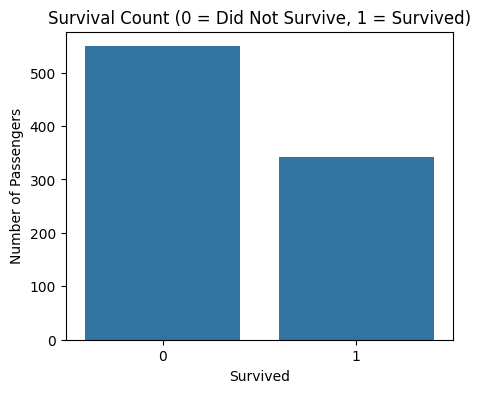

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #1: Class balance of the TARGET variable.
# Classification models can be misleadingly "accurate" on imbalanced data,
# so we must check the survival split before trusting accuracy later.
# ------------------------------------------------------------------
import matplotlib.pyplot as plt   # core plotting library
import seaborn as sns             # statistical plotting on top of matplotlib

plt.figure(figsize=(5, 4))
sns.countplot(x="Survived", data=titanic_df)   # countplot -> bar chart of category frequencies
plt.title("Survival Count (0 = Did Not Survive, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

# WHAT TO OBSERVE: More passengers did NOT survive than did -- this is a
# mild class imbalance, which is why we will look at precision/recall/F1,
# not just accuracy, during evaluation.


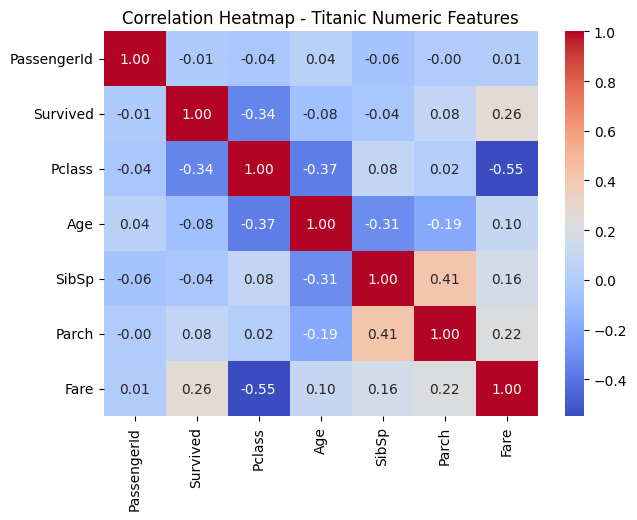

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #2: Correlation heatmap across numeric features + target.
# This shows which numeric features have any linear relationship with
# survival before we build the model.
# ------------------------------------------------------------------
numeric_df = titanic_df.select_dtypes(include=["float64", "int64"])   # keep only numeric columns

plt.figure(figsize=(7, 5))
correlation_matrix = numeric_df.corr()                                # pairwise correlation, -1 to 1
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")  # fmt=".2f" -> round labels to 2 decimals
plt.title("Correlation Heatmap - Titanic Numeric Features")
plt.show()

# WHAT TO OBSERVE: 'Pclass' (ticket class) has a notable NEGATIVE
# correlation with survival -- passengers in a "better" (lower-numbered)
# class were more likely to survive.


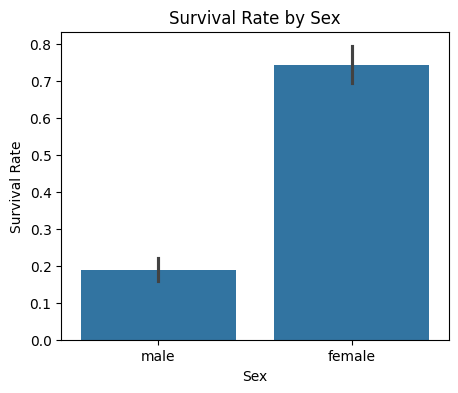

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #3: Survival rate by Sex -- historically one of the
# strongest predictors ("women and children first" evacuation policy).
# ------------------------------------------------------------------
plt.figure(figsize=(5, 4))
sns.barplot(x="Sex", y="Survived", data=titanic_df)   # barplot of MEAN survival rate per sex category
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

# WHAT TO OBSERVE: Female passengers have a dramatically higher survival
# rate than male passengers -- expect 'Sex' to be a very strong predictor
# once we build the model.


## 4. Data Preprocessing
Classification models need clean, fully-numeric input just like regression
models. We drop unusable columns, impute missing values, and encode
categorical features.


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Some columns cannot be meaningfully used as numeric predictors as-is:
# 'Name' and 'Ticket' are mostly unique free text, 'Cabin' is missing for
# most passengers, and 'PassengerId' is just a row index. We drop them to
# keep the model focused on genuinely predictive features.
# ------------------------------------------------------------------
columns_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]   # columns that add no clean predictive signal
titanic_clean_df = titanic_df.drop(columns=columns_to_drop)     # drop() -> remove these columns from the DataFrame

titanic_clean_df.head()   # confirm the dropped columns are gone


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# 'Age' has missing values. We impute with the MEDIAN age (robust to
# outliers) rather than dropping rows, so we keep every passenger's other
# information intact.
# ------------------------------------------------------------------
median_age = titanic_clean_df["Age"].median()                     # compute median of non-missing ages
titanic_clean_df["Age"] = titanic_clean_df["Age"].fillna(median_age)
# fillna() -> replaces every NaN in 'Age' with the median we just computed

print("Remaining missing values in 'Age':", titanic_clean_df["Age"].isnull().sum())   # should be 0 now


Remaining missing values in 'Age': 0


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# 'Embarked' has only a couple of missing values. For a categorical
# column, we impute with the MODE (most frequent category) rather than
# a numeric average, since categories have no meaningful "average".
# ------------------------------------------------------------------
mode_embarked = titanic_clean_df["Embarked"].mode()[0]   # mode() -> most frequent value; [0] -> take the first if tied
titanic_clean_df["Embarked"] = titanic_clean_df["Embarked"].fillna(mode_embarked)

print("Remaining missing values in 'Embarked':", titanic_clean_df["Embarked"].isnull().sum())   # should be 0 now


Remaining missing values in 'Embarked': 0


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# 'Sex' and 'Embarked' are categorical (text) columns, but Logistic
# Regression only understands numbers. One-Hot Encoding converts each
# category into its own 0/1 column.
# ------------------------------------------------------------------
categorical_columns = ["Sex", "Embarked"]   # the two remaining text columns that need encoding

# drop_first=True -> avoids the "dummy variable trap" (perfect multicollinearity
# between the one-hot columns, e.g. Sex_male and an implied Sex_female)
titanic_encoded_df = pd.get_dummies(titanic_clean_df, columns=categorical_columns, drop_first=True)

titanic_encoded_df.head()   # confirm new binary columns like 'Sex_male' now exist


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We separate the DataFrame into X (input features) and y (the target we
# want to predict: whether the passenger survived).
# ------------------------------------------------------------------
target_column = "Survived"   # the binary outcome we want to predict
feature_columns = [col for col in titanic_encoded_df.columns if col != target_column]
# list comprehension -> every column EXCEPT the target becomes an input feature

X = titanic_encoded_df[feature_columns]   # X -> DataFrame of input features
y = titanic_encoded_df[target_column]     # y -> Series of 0/1 survival labels

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance in y:")
print(y.value_counts(normalize=True).round(3))   # normalize=True -> show proportions instead of raw counts


X shape: (891, 8)
y shape: (891,)
Class balance in y:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We split into train/test sets BEFORE scaling, so information from the
# test set never leaks into preprocessing. stratify=y keeps the same
# survival ratio in both the train and test sets, which matters for
# imbalanced classification problems like this one.
# ------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# test_size=0.2 -> 80% train / 20% test split
# random_state=42 -> makes the split reproducible across runs
# stratify=y -> preserves the same proportion of survivors/non-survivors in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 712
Testing samples: 179


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# StandardScaler rescales numeric features (Age, Fare, etc.) to mean=0,
# std=1. Logistic Regression's optimizer converges faster and more
# reliably when features are on comparable scales.
# ------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()                        # create the scaler object
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform -> LEARN mean/std from train data, then scale it
X_test_scaled = scaler.transform(X_test)         # transform ONLY -> reuse train-set mean/std on test data
# IMPORTANT: We never call fit() on the test set -- that would leak test-set
# statistics into preprocessing, giving an overly optimistic evaluation.

print("Scaling complete. Training feature matrix shape:", X_train_scaled.shape)


Scaling complete. Training feature matrix shape: (712, 8)


## 5. Model Building
Logistic Regression predicts a PROBABILITY between 0 and 1 using the sigmoid
function: `sigmoid(z) = 1 / (1 + e^-z)`, where `z = b0 + b1*x1 + ... + bn*xn`
(the same linear combination as regular Linear Regression, just squeezed
through the sigmoid). A threshold (usually 0.5) then converts that
probability into a final 0/1 class prediction.


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We train scikit-learn's LogisticRegression on the scaled features. This
# is the classification counterpart to LinearRegression -- same linear
# combination of features, but passed through the sigmoid function to
# produce a probability instead of an unbounded numeric prediction.
# ------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

# max_iter=1000 -> allow the optimizer enough iterations to converge (default 100 can be too few)
# random_state=42 -> reproducible results across runs
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)   # learn coefficients from scaled training data

# Pair each feature name with its learned coefficient for readability
coefficients_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": logistic_model.coef_[0]   # coef_ is a 2D array for multi-class support; [0] -> our binary case
}).sort_values(by="Coefficient", ascending=False)

print("Intercept (b0):", round(logistic_model.intercept_[0], 4))
print()
print(coefficients_df)


Intercept (b0): -0.6569

      Feature  Coefficient
4        Fare     0.099599
6  Embarked_Q     0.080683
3       Parch    -0.067158
7  Embarked_S    -0.171784
2       SibSp    -0.262672
1         Age    -0.502878
0      Pclass    -0.928698
5    Sex_male    -1.269598


## 6. Evaluation

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We generate both class predictions (0/1) and predicted probabilities
# (needed later for the ROC-AUC curve) on the unseen test set.
# ------------------------------------------------------------------
y_pred = logistic_model.predict(X_test_scaled)              # final 0/1 class predictions (threshold = 0.5 default)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]
# predict_proba returns [P(class=0), P(class=1)] per row; we keep only P(survived=1)

print("First 5 predicted probabilities of survival:", y_pred_proba[:5].round(3))
print("First 5 predicted classes           :", y_pred[:5])


First 5 predicted probabilities of survival: [0.066 0.047 0.152 0.035 0.684]
First 5 predicted classes           : [0 0 0 0 1]


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Accuracy, precision, recall, and F1 each describe a different aspect of
# classifier performance -- accuracy alone can be misleading on imbalanced
# data (recall Section 3, where survival classes were not 50/50).
# ------------------------------------------------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)     # (correct predictions) / (total predictions)
precision = precision_score(y_test, y_pred)   # of predicted survivors, how many actually survived
recall = recall_score(y_test, y_pred)         # of actual survivors, how many did we correctly catch
f1 = f1_score(y_test, y_pred)                 # harmonic mean of precision and recall (balances both)

print(f"Accuracy  : {accuracy:.4f}  (>0.75-0.80 is considered solid for this dataset)")
print(f"Precision : {precision:.4f}  (of passengers we PREDICTED survived, this fraction actually did)")
print(f"Recall    : {recall:.4f}  (of passengers who ACTUALLY survived, this fraction we correctly identified)")
print(f"F1 Score  : {f1:.4f}  (balances precision and recall into one number; higher is better)")


Accuracy  : 0.8045  (>0.75-0.80 is considered solid for this dataset)
Precision : 0.7931  (of passengers we PREDICTED survived, this fraction actually did)
Recall    : 0.6667  (of passengers who ACTUALLY survived, this fraction we correctly identified)
F1 Score  : 0.7244  (balances precision and recall into one number; higher is better)


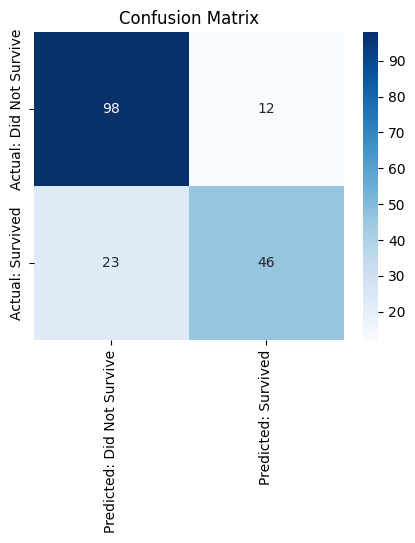

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# The confusion matrix breaks accuracy down into 4 exact counts: true
# positives, true negatives, false positives, and false negatives -- this
# is far more informative than a single accuracy number.
# ------------------------------------------------------------------
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)   # 2x2 array: rows=actual, columns=predicted

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Did Not Survive", "Predicted: Survived"],
            yticklabels=["Actual: Did Not Survive", "Actual: Survived"])
plt.title("Confusion Matrix")
plt.show()

# WHAT TO OBSERVE: The top-left and bottom-right cells are CORRECT
# predictions (true negatives, true positives). The top-right and
# bottom-left cells are ERRORS (false positives, false negatives).


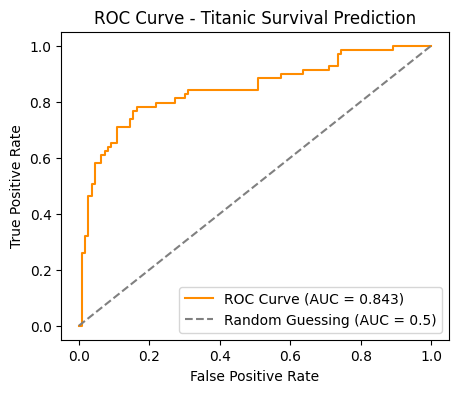

AUC Score: 0.8433  (>0.80 is considered a strong classifier for this dataset)


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# The ROC curve shows the trade-off between True Positive Rate and False
# Positive Rate at EVERY possible probability threshold, not just 0.5.
# AUC (Area Under Curve) summarizes this into one number: 0.5 = random
# guessing, 1.0 = perfect separation between classes.
# ------------------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)   # single-number summary of the whole ROC curve

plt.figure(figsize=(5, 4))
plt.plot(false_positive_rate, true_positive_rate, color="darkorange", label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guessing (AUC = 0.5)")   # baseline reference
plt.title("ROC Curve - Titanic Survival Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}  (>0.80 is considered a strong classifier for this dataset)")


## 7. Interpretation

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Logistic Regression coefficients represent change in LOG-ODDS, not raw
# probability. Exponentiating a coefficient converts it into an ODDS
# RATIO, which is much easier to explain in plain English.
# ------------------------------------------------------------------
import numpy as np   # needed for exponentiation below

coefficients_df["Odds_Ratio"] = np.exp(coefficients_df["Coefficient"])
# np.exp() -> converts a log-odds coefficient into an odds ratio
# Odds_Ratio > 1 -> increases odds of survival; Odds_Ratio < 1 -> decreases odds of survival

print(coefficients_df)
print()
top_row = coefficients_df.iloc[0]
print(f"Plain-English interpretation:")
print(f"- '{top_row['Feature']}' has the strongest positive association with survival "
      f"(odds ratio = {top_row['Odds_Ratio']:.2f}, meaning higher values of this feature "
      f"are associated with roughly {top_row['Odds_Ratio']:.1f}x the odds of survival, "
      f"holding other features constant).")


      Feature  Coefficient  Odds_Ratio
4        Fare     0.099599    1.104728
6  Embarked_Q     0.080683    1.084027
3       Parch    -0.067158    0.935048
7  Embarked_S    -0.171784    0.842161
2       SibSp    -0.262672    0.768994
1         Age    -0.502878    0.604788
0      Pclass    -0.928698    0.395068
5    Sex_male    -1.269598    0.280944

Plain-English interpretation:
- 'Fare' has the strongest positive association with survival (odds ratio = 1.10, meaning higher values of this feature are associated with roughly 1.1x the odds of survival, holding other features constant).


## 8. Practice Exercises (No Answers Provided)
1. Change the classification threshold from 0.5 to 0.3 (hint: `(y_pred_proba >= 0.3).astype(int)`). How do precision and recall change?
2. Engineer a new feature `FamilySize = SibSp + Parch + 1` and check if it improves F1-score.
3. Try dropping the `Fare` column and retrain. Does performance change much? Why might `Fare` and `Pclass` carry similar information?
4. Plot a bar chart of survival rate by `Pclass`. Does it match your intuition from the correlation heatmap?
5. Compare Logistic Regression against a `DecisionTreeClassifier` on the same train/test split using accuracy and F1-score.


## 9. Summary / Key Takeaways

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We record the exact library versions used, so results can be reproduced
# on any other machine before this notebook is pushed to GitHub.
# ------------------------------------------------------------------
import sklearn

print("Library versions used in this notebook:")
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("seaborn      :", sns.__version__)


Library versions used in this notebook:
pandas       : 3.0.2
numpy        : 2.4.4
scikit-learn : 1.8.0
matplotlib   : 3.10.8
seaborn      : 0.13.2


**Key Takeaways**
- Logistic Regression is used for CLASSIFICATION (predicting a category), not regression (predicting a continuous number).
- The sigmoid function converts a linear combination of features into a probability between 0 and 1.
- On imbalanced datasets, accuracy alone can be misleading — always check precision, recall, F1-score, and the confusion matrix together.
- ROC-AUC summarizes classifier performance across ALL possible decision thresholds, not just the default 0.5.
- Exponentiating a Logistic Regression coefficient gives an odds ratio, which is easier to explain to non-technical stakeholders than the raw log-odds coefficient.
